In [20]:
import json
from pathlib import Path
import os
import glob
from functools import reduce

from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, auc, roc_auc_score
import matplotlib.pyplot as plt
from upsetplot import from_contents, plot, UpSet
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [126]:
all_jsons_fs = []
all_jsons_fr = []

dirs_fs = ["FSAll_cdf"]
dirs_fr = ["FRAll_cdf"]

for dataset in os.scandir("/home/antoine/df-benchmark/exps_old"):
    if dataset.name in dirs_fs:
        dataset_jsons = glob.glob(os.path.join(dataset, "**/video-level/*.json"), recursive=True)
        for e in dataset_jsons:
            all_jsons_fs.append(e)

for dataset in os.scandir("/home/antoine/df-benchmark/exps_old"):
    if dataset.name in dirs_fr:
        dataset_jsons = glob.glob(os.path.join(dataset, "**/video-level/*.json"), recursive=True)
        for e in dataset_jsons:
            all_jsons_fr.append(e)

In [127]:
def fixed_tpr(file, tpr_goal=0.9):
    with open(file) as preds_file:
        model_name = file.split("/")[-5]
        train_set = file.split("/")[-4]

        if train_set == "train_on_ff-orig":
            train_set = "ff-orig"
        elif train_set == "train_on_df40-fr-ff":
            train_set = "df40-fr-ff"
        elif train_set == "train_on_df40-fs-ff":
            train_set = "df40-fs-ff"
        elif train_set == "train_on_df40-all-ff":
            train_set = "df40-all-ff"

        preds_dict = json.load(preds_file)

        labels = [values["label"] for video, values in preds_dict.items()]
        raw_preds = [values["pred"] for video, values in preds_dict.items()]

        fpr, tpr, thresholds = roc_curve(labels, raw_preds)

        idx = np.argmax(tpr >= tpr_goal)

        fpr_at_goal = fpr[idx]
        threshold_at_goal = thresholds[idx]

        

        return model_name, train_set, fpr_at_goal, threshold_at_goal

        print(f"Pour détecter {tpr[idx]*100:.1f}% des deepfakes :")
        print(f"-> Le taux de fausses alarmes (FPR) sera de {fpr_at_90*100:.1f}%")
        print(f"-> Il faudra régler le seuil de décision du modèle à {threshold_at_90:.100}\n")


In [128]:
fprs_80 = []

tpr_goal = 0.8

for j in all_jsons_fs:
    model_name, train_set, fpr_at_goal, threshold_at_goal = fixed_tpr(j, tpr_goal=tpr_goal)

    row = {
        "model_name": model_name,
        "train_dataset" : train_set,
        "test_dataset": "FSAll_cdf",
        "fpr_at_target": fpr_at_goal,
        "fpr_at_target_percent": fpr_at_goal * 100,
        "threshold_at_target": threshold_at_goal,
        "target_tpr": tpr_goal,
        "file": j
    }

    fprs_80.append(row)

for j in all_jsons_fr:
    model_name, train_set, fpr_at_goal, threshold_at_goal = fixed_tpr(j, tpr_goal=tpr_goal)

    row = {
        "model_name": model_name,
        "train_dataset" : train_set,
        "test_dataset": "FRAll_cdf",
        "fpr_at_target": fpr_at_goal,
        "fpr_at_target_percent": fpr_at_goal * 100,
        "threshold_at_target": threshold_at_goal,
        "target_tpr": tpr_goal,
        "file": j
    }

    fprs_80.append(row)

df_fprs_80 = pd.DataFrame(fprs_80)

In [129]:
fprs_best_to_worst = df_fprs_80.sort_values(by="fpr_at_target", ascending=True)

fprs_best_to_worst.to_csv("analysis/fprs-df40-cdf.csv")

In [130]:
palette = {
    'ff-orig': '#4C72B0',
    'df40-fr-ff': '#C44E52',
    'df40-fs-ff':'#D5BB67',
    'df40-all-ff': '#55A868'
}

train_datasets_order = ["df40-all-ff", "df40-fs-ff", "df40-fr-ff", "ff-orig"]

In [151]:
def show_bar_graph(df, x_col, title, xlabel):
    plt.figure(figsize=(10, 10))

    ax = sns.barplot(
        data=df, 
        x=x_col, 
        y=df.index, 
        hue='train_dataset',
        hue_order=train_datasets_order,
        orient='h',
        dodge=False,
        palette=palette,
    )

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['model_name'])

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Model')
    #plt.xlim(0.4, 1.0)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    #plt.legend(title='Training Set', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.legend(title='Training Set', loc='upper right')

    plt.tight_layout()
    plt.show()

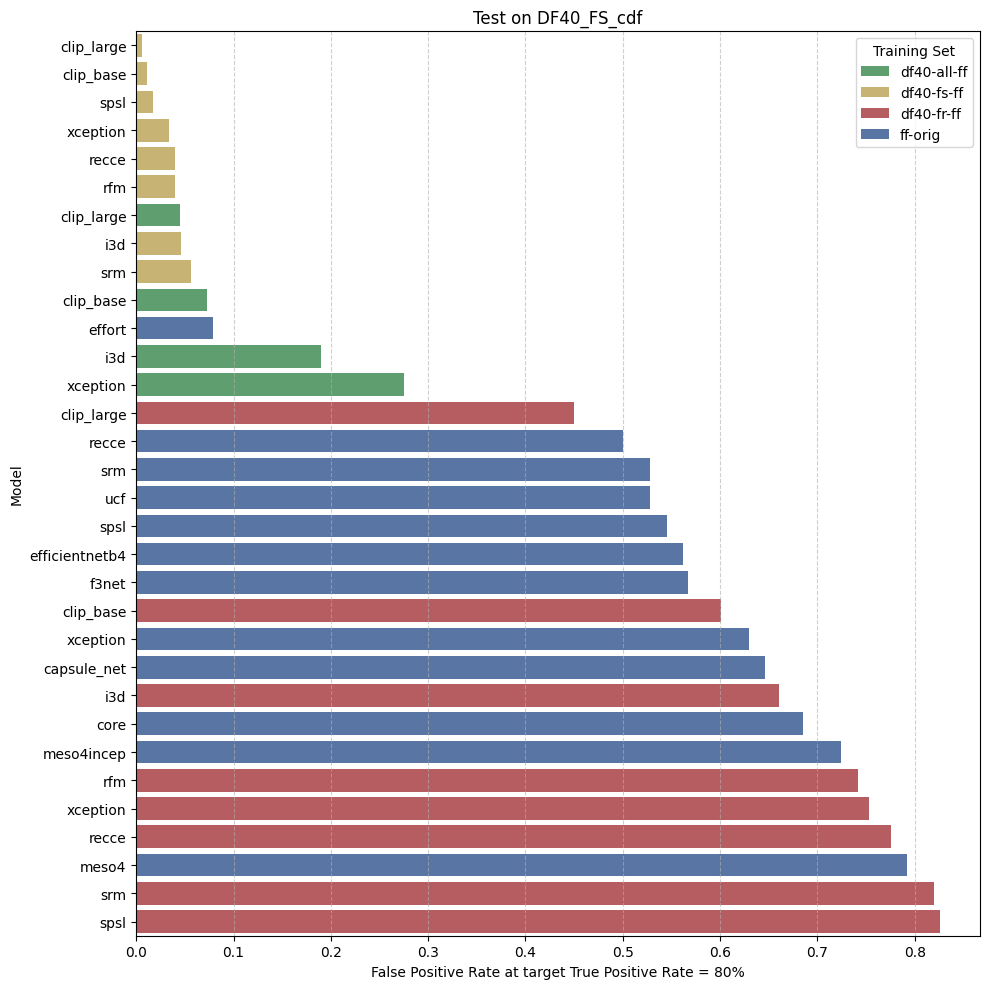

In [145]:
fprs_fs = df_fprs_80[df_fprs_80["test_dataset"] == "FSAll_cdf"]
fprs_best_fs = fprs_fs.sort_values(by="fpr_at_target", ascending=True)
fprs_best_fs = fprs_best_fs.reset_index()
show_bar_graph(fprs_best_fs, "fpr_at_target", "Test on DF40_FS_cdf", "False Positive Rate at target True Positive Rate = 80%")

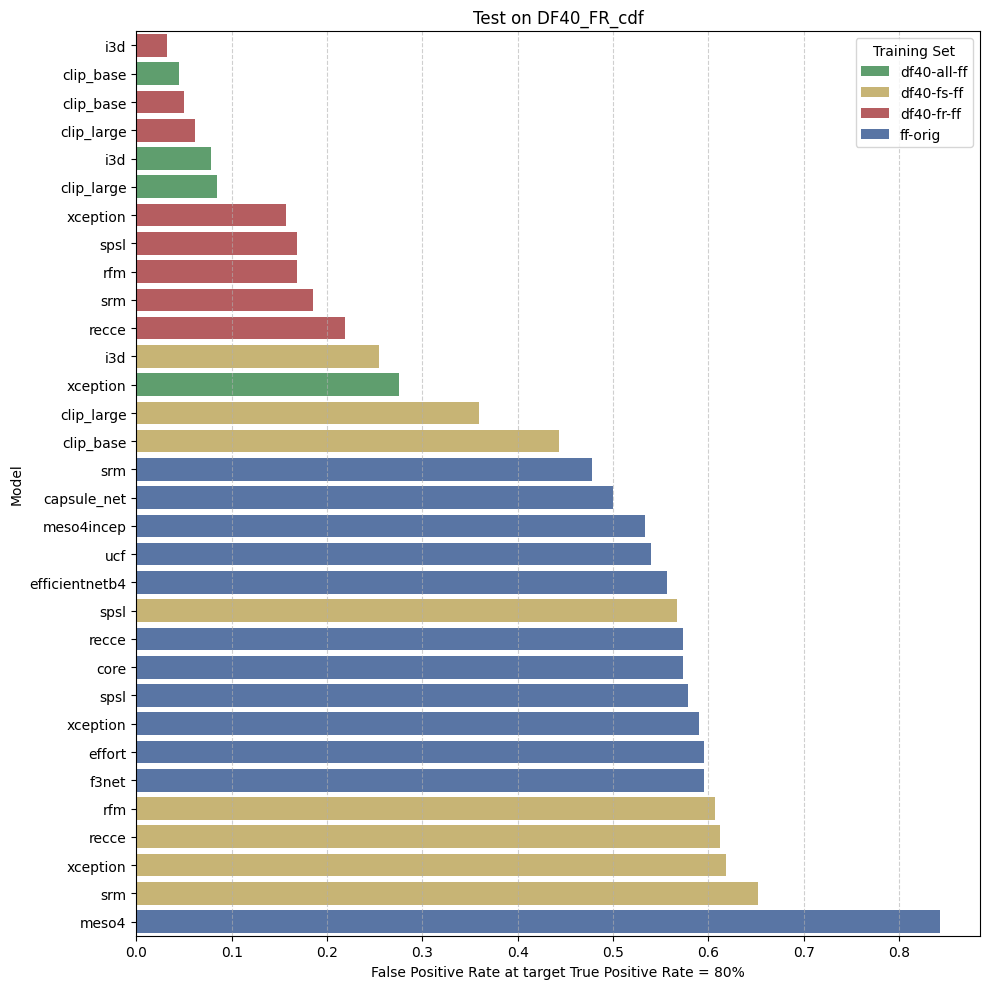

In [146]:
fprs_fr = df_fprs_80[df_fprs_80["test_dataset"] == "FRAll_cdf"]
fprs_best_fr = fprs_fr.sort_values(by="fpr_at_target", ascending=True)
fprs_best_fr = fprs_best_fr.reset_index()
show_bar_graph(fprs_best_fr, "fpr_at_target", "Test on DF40_FR_cdf", "False Positive Rate at target True Positive Rate = 80%")

# Video AUC and fixed tpr for both datasets

In [134]:
df_comparaison = pd.merge(
    fprs_fs, 
    fprs_fr, 
    on=['model_name', 'train_dataset'], 
    suffixes=('_FS', '_FR')
)
df_comparaison = df_comparaison.drop(columns=['test_dataset_FS', 'test_dataset_FR', 'target_tpr_FR'])
df_comparaison = df_comparaison.rename(columns={"target_tpr_FS": "target_tpr"})

In [135]:
detectors_video_preds = {}

for _, row in df_comparaison.iterrows():
    preds_fs = None
    preds_fr = None

    train_set = row["file_FS"].split("/")[-4]

    if train_set == "train_on_ff-orig":
        train_set = "ff-orig"
    elif train_set == "train_on_df40-fr-ff":
        train_set = "df40-fr-ff"
    elif train_set == "train_on_df40-fs-ff":
        train_set = "df40-fs-ff"
    elif train_set == "train_on_df40-all-ff":
        train_set = "df40-all-ff"

    
    with open(row["file_FS"]) as file:
        preds_fs = json.load(file)
    with open(row["file_FR"]) as file:
        preds_fr = json.load(file)

    preds_all = preds_fs | preds_fr

    detectors_video_preds[f"{row["model_name"]}#{train_set}"] = preds_all

In [136]:
video_preds_list = []
for detector, video_preds in detectors_video_preds.items():
    detector_preds = []
    detector_labels = []
    for video_name, pred_label in video_preds.items():
        detector_preds.append(pred_label["pred"])
        detector_labels.append(pred_label["label"])

    video_auc = roc_auc_score(detector_labels, detector_preds)

    model_name = detector.split("#")[0]
    train_set = detector.split("#")[1]

    fpr, tpr, thresholds = roc_curve(detector_labels, detector_preds)

    target_tpr = 0.8

    idx = np.argmax(tpr >= target_tpr)

    fpr_at_goal = fpr[idx]
    threshold_at_goal = thresholds[idx]

    video_preds_list.append({"model_name": model_name, "train_dataset": train_set, "video_auc_both": video_auc, "target_tpr": target_tpr, "fpr_at_target": fpr_at_goal})

df_video_preds = pd.DataFrame(video_preds_list)

In [137]:
df_video_preds

,model_name,train_dataset,video_auc_both,target_tpr,fpr_at_target
0,core,ff-orig,0.679001,0.8,0.612360
1,capsule_net,ff-orig,0.704323,0.8,0.573034
2,meso4,ff-orig,0.487151,0.8,0.831461
3,clip_base,df40-fs-ff,0.854432,0.8,0.264045
4,clip_base,df40-fr-ff,0.835783,0.8,0.320225
5,clip_base,df40-all-ff,0.942647,0.8,0.056180
6,meso4incep,ff-orig,0.655322,0.8,0.640449
7,rfm,df40-fs-ff,0.789138,0.8,0.426966
8,rfm,df40-fr-ff,0.738689,0.8,0.522472
9,efficientnetb4,ff-orig,0.723650,0.8,0.556180


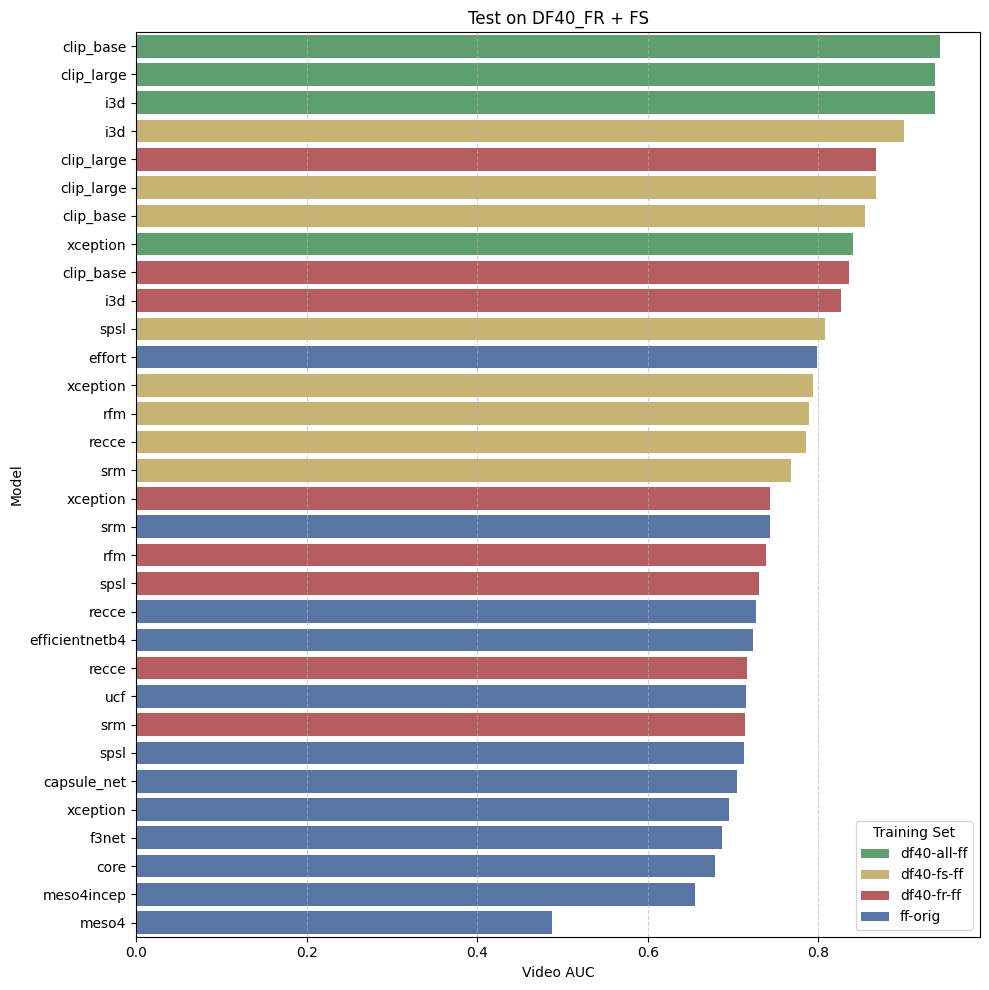

In [149]:
df_video_preds = df_video_preds.sort_values(by="video_auc_both", ascending=False)
df_video_preds = df_video_preds.reset_index(drop=True)
show_bar_graph(df_video_preds, "video_auc_both", "Test on DF40_FR + FS", "Video AUC")

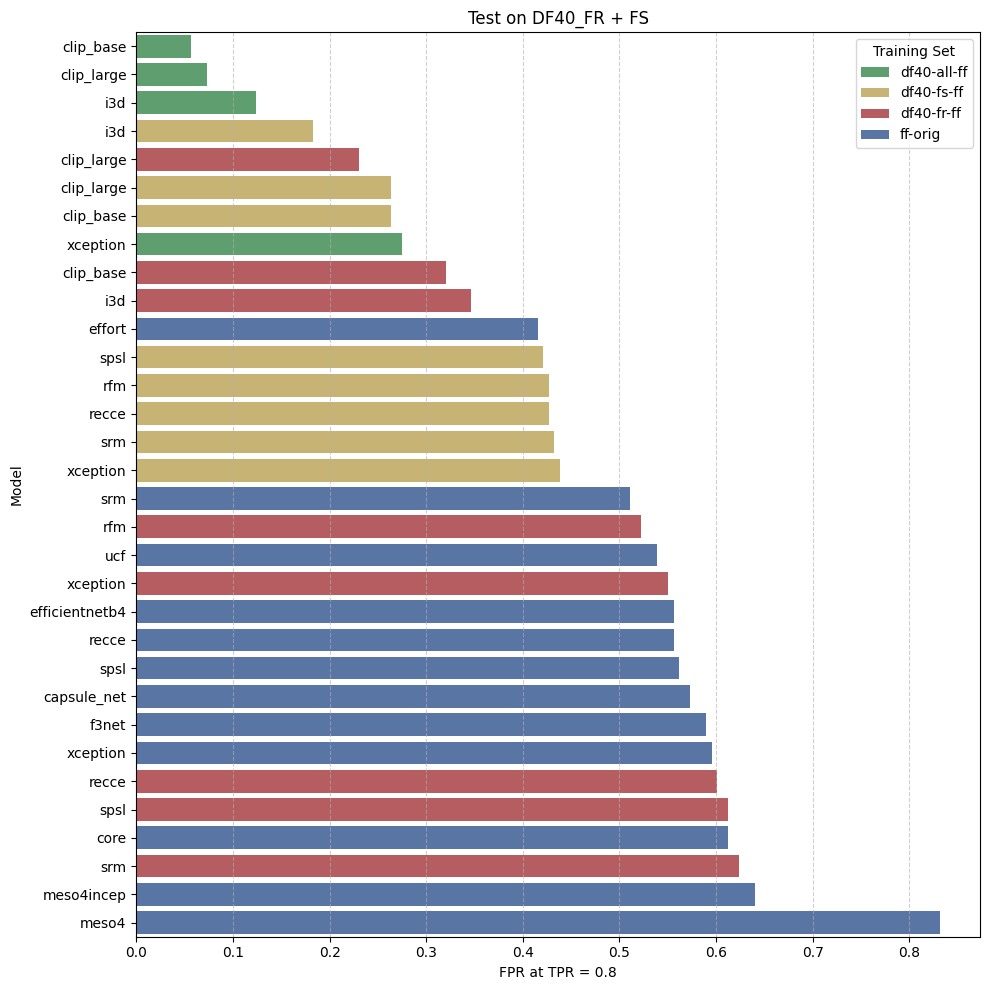

In [152]:
df_video_fpr = df_video_preds.sort_values(by="fpr_at_target", ascending=True)
df_video_fpr = df_video_fpr.reset_index(drop=True)
show_bar_graph(df_video_fpr, "fpr_at_target", "Test on DF40_FR + FS", "FPR at TPR = 0.8")

In [2]:
selected_models = [
    "exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T10-31-50A.json",
    "exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T17-02-42A.json",
    "exps/FSAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T15-42-41A.json",
    "exps/FSAll_cdf/srm/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-55-23A.json",
    "exps/FSAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-11-04A.json",
    "exps/FSAll_cdf/rfm/train_on_df40-fs-ff/preds/video-level/2026-02-23T13-48-14A.json",
    "exps/FSAll_cdf/recce/train_on_df40-fs-ff/preds/video-level/2026-02-23T13-24-25A.json"

]



for path in selected_models:
    fs_video_list = []
    fs_video_labels = []
    with open(path) as file:
        all_info = json.load(file)
        video_infos = all_info["vids_results"]

        model_name = all_info["model_name"]
        print(model_name)
        train_dataset = all_info["train_dataset"]
        if train_dataset == "train_on_ff-orig":
            train_dataset = "ff-orig"
        elif train_dataset == "train_on_df40-fr-ff":
            train_dataset = "df40-fr-ff"
        elif train_dataset == "train_on_df40-fs-ff":
            train_dataset = "df40-fs-ff"
        elif train_dataset == "train_on_df40-all-ff":
            train_dataset = "df40-all-ff"
        test_dataset = all_info["test_dataset"]

        detector_preds = []
        detector_logits = []

        for video_path, infos in video_infos.items():
            fs_video_list.append(video_path)
            fs_video_labels.append(infos["label"])

            detector_preds.append(infos["pred"])
            #detector_logits.append(infos["logit"])

        print(len(detector_preds))
        print(len(fs_video_labels))

        detector_preds = pd.Series(detector_preds)

        fpr, tpr, thresholds = roc_curve(fs_video_labels, detector_preds)

        target_tpr = 0.8

        idx = np.argmax(tpr >= target_tpr)

        fpr_at_goal = fpr[idx]
        threshold_at_goal = thresholds[idx]

        detector_choices = []

        print(len(detector_preds))

        for p in detector_preds:
            if p >= threshold_at_goal:
                detector_choices.append(1)
            else:
                detector_choices.append(0)

    df_export = pd.DataFrame()
    df_export["video_path"] = fs_video_list
    df_export["label"] = fs_video_labels
    df_export["pred"] = pd.Series(detector_preds)
    df_export["choice"] = pd.Series(detector_choices)
    #df_export[f"logit_{model_name}#{train_dataset}"] = detector_logits

    df_export.to_csv(f"analysis/selected_models_preds/fs_all/{model_name}#{train_dataset}.csv")
            

clip_base
5339
5339
5339
i3d
4866
4866
4866
xception
5339
5339
5339
srm
5339
5339
5339
spsl
5339
5339
5339
rfm
5339
5339
5339
recce
5339
5339
5339


In [76]:
csvs = []

for file in os.scandir("analysis/selected_models_preds/fs_all/"):
    csvs.append(file)


dataframes = []

for i, file in enumerate(csvs):
    df = pd.read_csv(file)
    
    if i == 0:
        df_propre = df[['video_path', 'label', 'choice']].copy()
    else:
        df_propre = df[['video_path', 'choice']].copy()
        
    df_propre = df_propre.rename(columns={'choice': f'{file.name}'})
    
    dataframes.append(df_propre)

df_finale = reduce(lambda left, right: pd.merge(left, right, on='video_path', how='outer'), dataframes)

In [77]:
df_finale = df_finale.reindex(sorted(df_finale.columns), axis=1)

In [78]:
display(df_finale)

,clip_base#df40-all-ff.csv,i3d#df40-all-ff.csv,label,recce#df40-fs-ff.csv,rfm#df40-fs-ff.csv,spsl#df40-fs-ff.csv,srm#df40-fs-ff.csv,video_path,xception#df40-all-ff.csv
0,0,0.0,0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0
1,1,NaN,0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
2,0,NaN,0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0
3,0,0.0,0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
4,0,0.0,0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
...,...,...,...,...,...,...,...,...,...
5334,1,1.0,1,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
5335,1,1.0,1,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
5336,1,1.0,1,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
5337,1,1.0,1,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1


In [6]:
errors_by_detec = {}
errors_by_detec_bin = {}

for index, row in df_finale.iterrows():
    video_path = None
    name = None
    label = None
    for col in row.items():
        if col[0] == "video_path":
            video_path = col[1]
        elif col[0] == "label":
            label = col[1]
            continue
        else:
            if col[1] != label:
                if col[0] in errors_by_detec.keys():
                    if pd.isna(col[1]):
                        errors_by_detec[col[0]].append(video_path)
                        errors_by_detec_bin[col[0]].append(1)
                    else:
                        errors_by_detec[col[0]].append(video_path)
                        errors_by_detec_bin[col[0]].append(1)
                else:
                    errors_by_detec[col[0]] = [video_path]
                    errors_by_detec_bin[col[0]] = [1]

            else:
                if col[0] in errors_by_detec.keys():
                    errors_by_detec_bin[col[0]].append(0)
                else:
                    errors_by_detec_bin[col[0]] = [0]

            

In [7]:
list(errors_by_detec.keys())

['i3d#df40-all-ff.csv',
 'xception#df40-all-ff.csv',
 'clip_base#df40-all-ff.csv',
 'rfm#df40-fs-ff.csv',
 'spsl#df40-fs-ff.csv',
 'srm#df40-fs-ff.csv',
 'recce#df40-fs-ff.csv']

/home/antoine/miniconda3/envs/df40/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/antoine/miniconda3/envs/df40/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

<Figure size 1500x800 with 0 Axes>

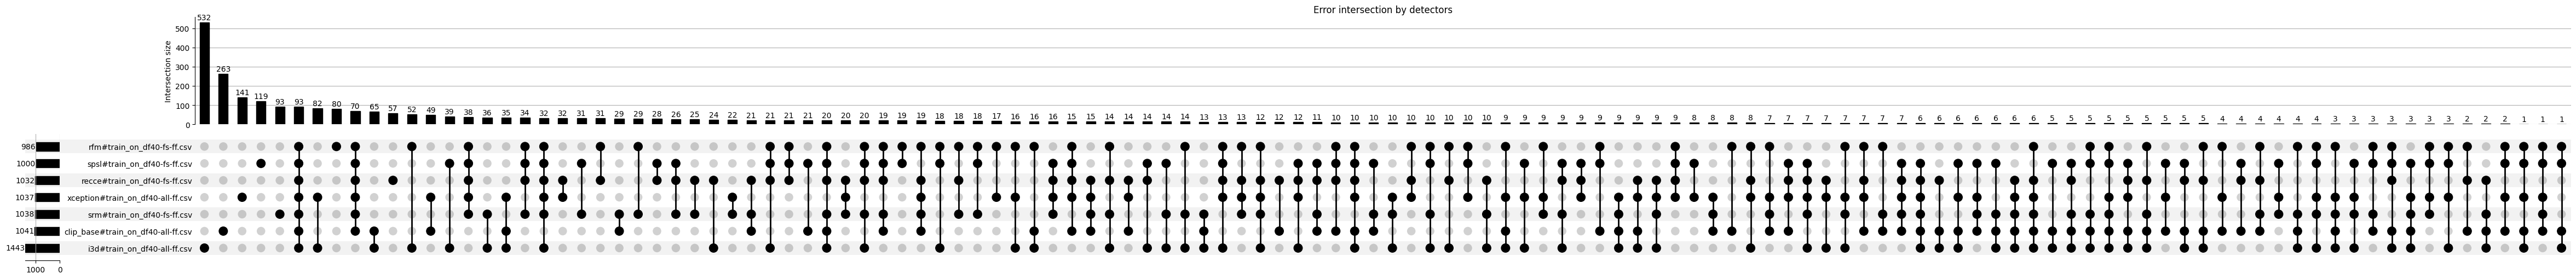

In [97]:
data_for_upset = from_contents(errors_by_detec)

plt.figure(figsize=(15, 8))
plot(data_for_upset, show_counts=True, sort_by="cardinality")
plt.title("Error intersection by detectors")
plt.show()

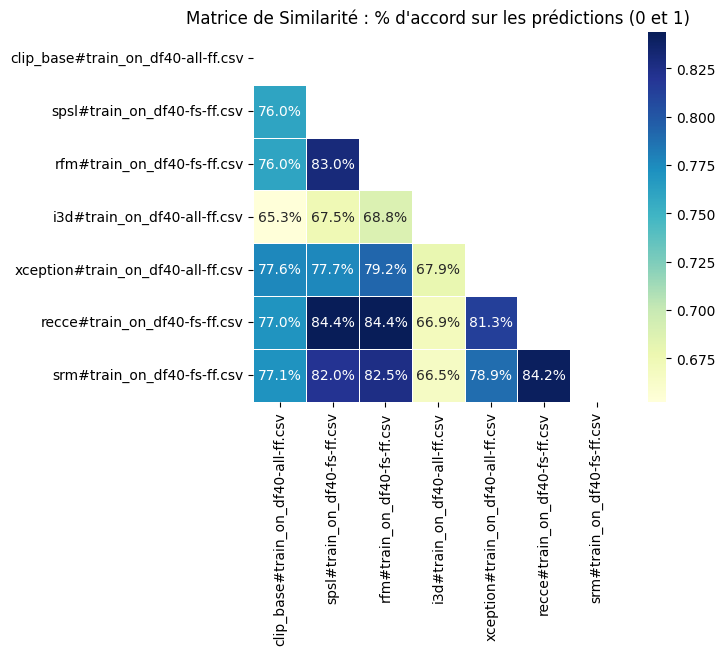

In [108]:
def calc_similarity_matrix(df):
    cols = df.columns
    n = len(cols)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            # % de fois où la prédiction est identique
            agreement = (df.iloc[:, i] == df.iloc[:, j]).mean()
            matrix[i, j] = agreement
            
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_sim = calc_similarity_matrix(df_finale.drop(["video_path", "label"], axis='columns'))

# 3. Affichage du Heatmap
mask = np.triu(np.ones_like(df_sim, dtype=bool))
sns.heatmap(
    df_sim, 
    mask=mask,         # <-- C'est ici que la magie opère !
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,         # Optionnel : force les cases à être carrées
    linewidths=0.5       # Optionnel : ajoute un petit espace entre les cases
)

plt.title("Matrice de Similarité : % d'accord sur les prédictions (0 et 1)")
plt.show()

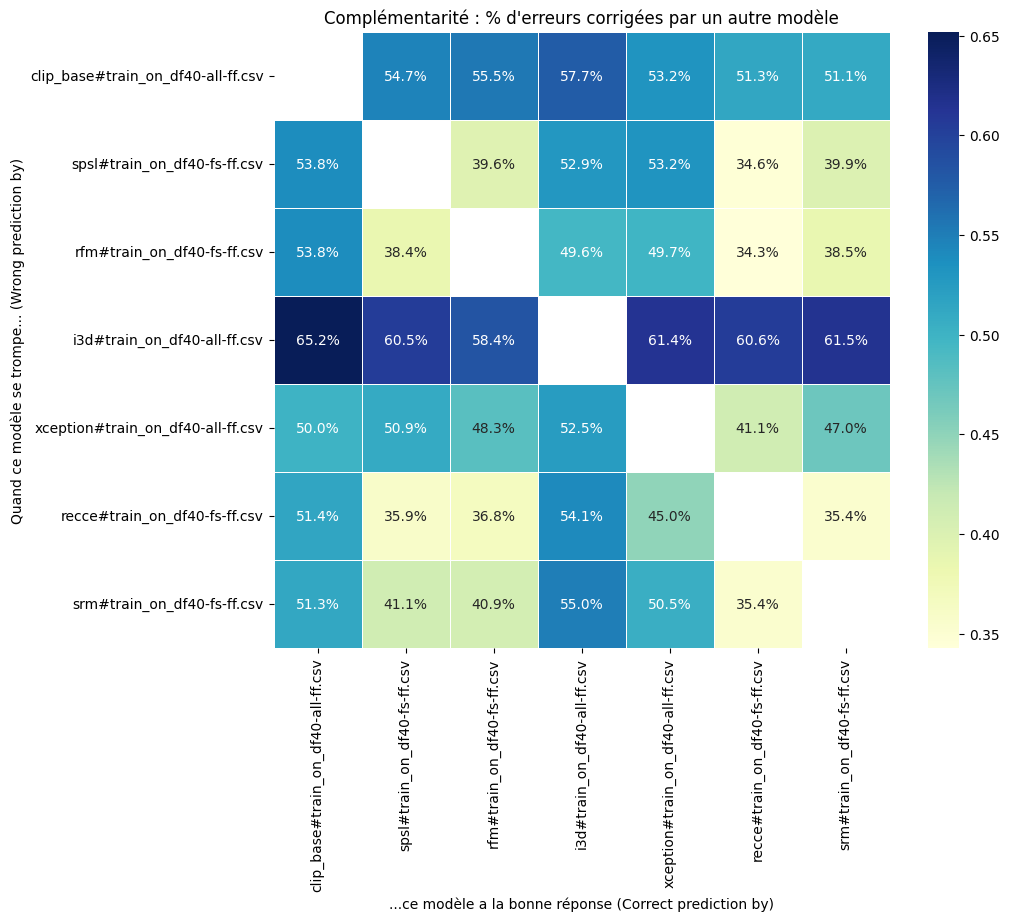

In [109]:
def calc_complementarity(df):
    cols = df.columns
    matrix = np.zeros((len(cols), len(cols)))
    
    for i, det_a in enumerate(cols):
        for j, det_b in enumerate(cols):
            if i == j:
                matrix[i, j] = 1.0 # Un détecteur ne s'aide pas lui-même
                continue
            
            # Masque : vidéos où A a FAUX (0)
            errors_a = df[det_a] == 0
            
            if errors_a.sum() == 0:
                matrix[i, j] = 0 # A n'a aucune erreur, B n'ajoute rien
            else:
                # % de fois où B a JUSTE (1) quand A a FAUX (0)
                savings = (df.loc[errors_a, det_b] == 1).mean()
                matrix[i, j] = savings
                
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_comp = calc_complementarity(df_finale.drop(["video_path", "label"], axis='columns'))

# 1. Création d'un masque uniquement pour la diagonale
# np.eye crée une matrice avec des 1 sur la diagonale et des 0 ailleurs
masque_diagonale = np.eye(len(df_comp), dtype=bool)

# 2. Affichage du Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_comp, 
    mask=masque_diagonale, # On cache juste la diagonale
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,
    linewidths=0.5
)

plt.title("Complémentarité : % d'erreurs corrigées par un autre modèle")
plt.ylabel("Quand ce modèle se trompe... (Wrong prediction by)")
plt.xlabel("...ce modèle a la bonne réponse (Correct prediction by)")

plt.show()

In [110]:
df_comp

,clip_base#train_on_df40-all-ff.csv,spsl#train_on_df40-fs-ff.csv,rfm#train_on_df40-fs-ff.csv,i3d#train_on_df40-all-ff.csv,xception#train_on_df40-all-ff.csv,recce#train_on_df40-fs-ff.csv,srm#train_on_df40-fs-ff.csv
clip_base#train_on_df40-all-ff.csv,1.000000,0.546521,0.554904,0.576697,0.532272,0.512992,0.511316
spsl#train_on_df40-fs-ff.csv,0.538396,1.000000,0.395904,0.529010,0.532423,0.345563,0.399317
rfm#train_on_df40-fs-ff.csv,0.538261,0.384348,1.000000,0.495652,0.497391,0.342609,0.385217
i3d#train_on_df40-all-ff.csv,0.651643,0.604695,0.584038,1.000000,0.614085,0.605634,0.615023
xception#train_on_df40-all-ff.csv,0.500448,0.509400,0.482543,0.524620,1.000000,0.410922,0.470009
recce#train_on_df40-fs-ff.csv,0.514214,0.358696,0.367893,0.540970,0.449833,1.000000,0.353679
srm#train_on_df40-fs-ff.csv,0.512542,0.411371,0.408863,0.550167,0.505017,0.353679,1.000000


In [58]:
selected_models = [
    "exps_old/FRAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-19T23-52-02A.json",
    "exps_old/FRAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-20T11-27-38A.json",
    "exps_old/FRAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-20T15-58-28A.json",
    "exps_old/FRAll_cdf/srm/train_on_df40-fr-ff/preds/video-level/2026-02-20T15-16-26A.json",
    "exps_old/FRAll_cdf/spsl/train_on_df40-fr-ff/preds/video-level/2026-02-20T13-56-34A.json",
    "exps_old/FRAll_cdf/rfm/train_on_df40-fr-ff/preds/video-level/2026-02-20T13-22-51A.json",
    "exps_old/FRAll_cdf/recce/train_on_df40-fr-ff/preds/video-level/2026-02-20T13-00-45A.json"

    "exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T10-31-50A.json",
    "exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T17-02-42A.json",
    "exps/FSAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T15-42-41A.json",
    "exps/FSAll_cdf/srm/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-55-23A.json",
    "exps/FSAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-11-04A.json",
    "exps/FSAll_cdf/rfm/train_on_df40-fs-ff/preds/video-level/2026-02-23T13-48-14A.json",
    "exps/FSAll_cdf/recce/train_on_df40-fs-ff/preds/video-level/2026-02-23T13-24-25A.json"

]



for path in selected_models:
    fr_video_list = []
    fr_video_labels = []
    with open(path) as file:
        all_info = json.load(file)

        model_name = path.split("/")[-5]
        print(model_name)
        train_dataset = path.split("/")[-4]
        if train_dataset == "train_on_ff-orig":
            train_dataset = "ff-orig"
        elif train_dataset == "train_on_df40-fr-ff":
            train_dataset = "df40-fr-ff"
        elif train_dataset == "train_on_df40-fs-ff":
            train_dataset = "df40-fs-ff"
        elif train_dataset == "train_on_df40-all-ff":
            train_dataset = "df40-all-ff"
        test_dataset = path.split("/")[-6]

        detector_preds = []
        detector_logits = []

        for video_path, infos in all_info.items():
            fr_video_list.append(video_path)
            fr_video_labels.append(infos["label"])

            detector_preds.append(infos["pred"])
            #detector_logits.append(infos["logit"])

        print(len(detector_preds))
        print(len(fr_video_labels))

        detector_preds = pd.Series(detector_preds)

        fpr, tpr, thresholds = roc_curve(fr_video_labels, detector_preds)

        target_tpr = 0.8

        idx = np.argmax(tpr >= target_tpr)

        fpr_at_goal = fpr[idx]
        threshold_at_goal = thresholds[idx]

        detector_choices = []

        print(len(detector_preds))

        for p in detector_preds:
            if p >= threshold_at_goal:
                detector_choices.append(1)
            else:
                detector_choices.append(0)

    df_export = pd.DataFrame()
    df_export["video_path"] = fr_video_list
    df_export["label"] = fr_video_labels
    df_export["pred"] = pd.Series(detector_preds)
    df_export["choice"] = pd.Series(detector_choices)
    #df_export[f"logit_{model_name}#{train_dataset}"] = detector_logits

    df_export.to_csv(f"analysis/selected_models_preds/fr_all/{model_name}#{train_dataset}.csv")
            

clip_base
7948
7948
7948
i3d
6544
6544
6544
xception
7948
7948
7948
srm
7948
7948
7948
spsl
7948
7948
7948
rfm
7948
7948
7948
recce
7948
7948
7948


In [70]:
csvs = []

for file in os.scandir("analysis/selected_models_preds/fr_all/"):
    csvs.append(file)


dataframes = []

for i, file in enumerate(csvs):
    df = pd.read_csv(file)
    
    if i == 0:
        df_propre = df[['video_path', 'label', 'choice']].copy()
    else:
        df_propre = df[['video_path', 'choice']].copy()
        
    df_propre = df_propre.rename(columns={'choice': f'{file.name}'})
    
    dataframes.append(df_propre)

df_finale = reduce(lambda left, right: pd.merge(left, right, on='video_path', how='outer'), dataframes)

In [71]:
df_finale = df_finale.reindex(sorted(df_finale.columns), axis=1)

In [72]:
df_finale

,clip_base#df40-all-ff.csv,i3d#df40-all-ff.csv,label,recce#df40-fr-ff.csv,rfm#df40-fr-ff.csv,spsl#df40-fr-ff.csv,srm#df40-fr-ff.csv,video_path,xception#df40-all-ff.csv
0,0,0.0,0.0,0,0,0,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0
1,1,NaN,NaN,1,1,0,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
2,0,NaN,NaN,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0
3,0,0.0,0.0,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
4,0,0.0,0.0,0,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
...,...,...,...,...,...,...,...,...,...
7943,0,NaN,NaN,1,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
7944,0,NaN,NaN,0,1,1,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1
7945,0,NaN,NaN,0,0,0,1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0
7946,0,1.0,1.0,0,0,0,0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1


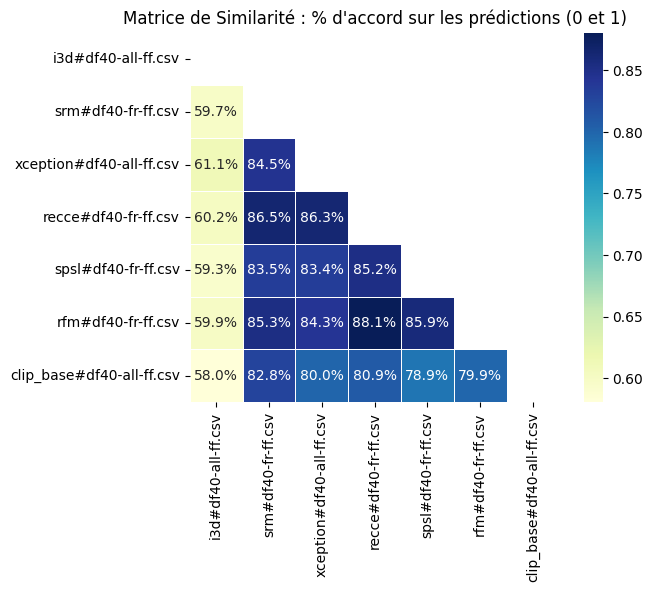

In [10]:
def calc_similarity_matrix(df):
    cols = df.columns
    n = len(cols)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            # % de fois où la prédiction est identique
            agreement = (df.iloc[:, i] == df.iloc[:, j]).mean()
            matrix[i, j] = agreement
            
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_sim = calc_similarity_matrix(df_finale.drop(["video_path", "label"], axis='columns'))

# 3. Affichage du Heatmap
mask = np.triu(np.ones_like(df_sim, dtype=bool))
sns.heatmap(
    df_sim, 
    mask=mask,         # <-- C'est ici que la magie opère !
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,         # Optionnel : force les cases à être carrées
    linewidths=0.5       # Optionnel : ajoute un petit espace entre les cases
)

plt.title("Matrice de Similarité : % d'accord sur les prédictions (0 et 1)")
plt.show()

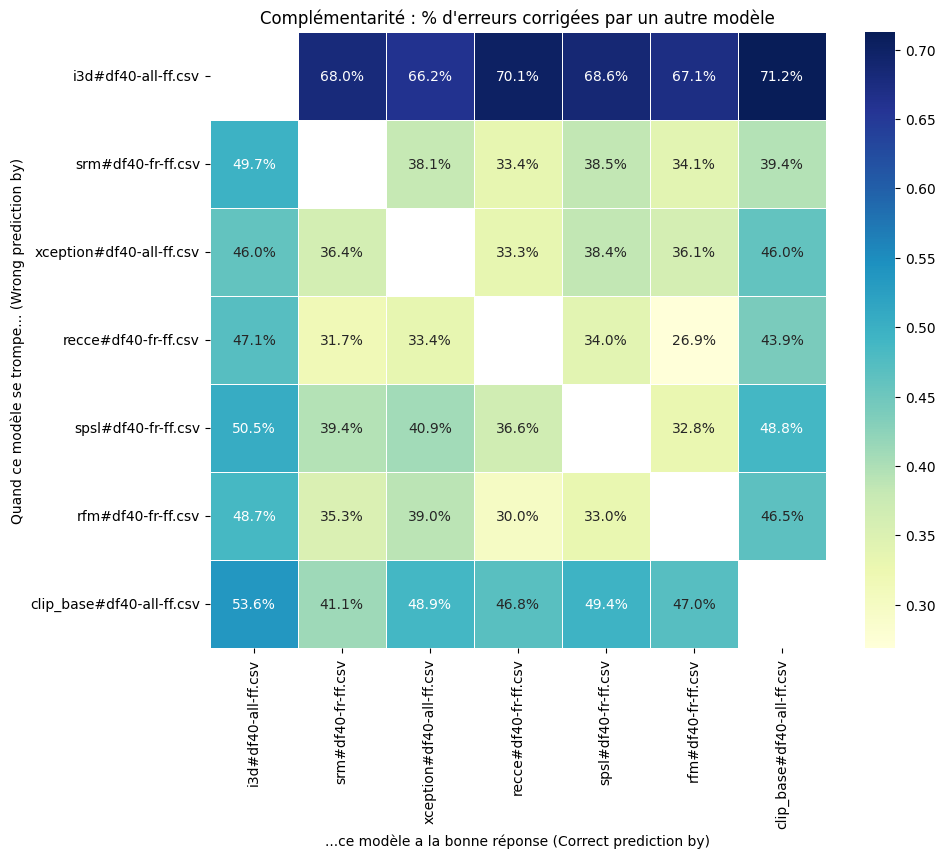

In [11]:
def calc_complementarity(df):
    cols = df.columns
    matrix = np.zeros((len(cols), len(cols)))
    
    for i, det_a in enumerate(cols):
        for j, det_b in enumerate(cols):
            if i == j:
                matrix[i, j] = 1.0 # Un détecteur ne s'aide pas lui-même
                continue
            
            # Masque : vidéos où A a FAUX (0)
            errors_a = df[det_a] == 0
            
            if errors_a.sum() == 0:
                matrix[i, j] = 0 # A n'a aucune erreur, B n'ajoute rien
            else:
                # % de fois où B a JUSTE (1) quand A a FAUX (0)
                savings = (df.loc[errors_a, det_b] == 1).mean()
                matrix[i, j] = savings
                
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_comp = calc_complementarity(df_finale.drop(["video_path", "label"], axis='columns'))

# 1. Création d'un masque uniquement pour la diagonale
# np.eye crée une matrice avec des 1 sur la diagonale et des 0 ailleurs
masque_diagonale = np.eye(len(df_comp), dtype=bool)

# 2. Affichage du Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_comp, 
    mask=masque_diagonale, # On cache juste la diagonale
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,
    linewidths=0.5
)

plt.title("Complémentarité : % d'erreurs corrigées par un autre modèle")
plt.ylabel("Quand ce modèle se trompe... (Wrong prediction by)")
plt.xlabel("...ce modèle a la bonne réponse (Correct prediction by)")

plt.show()

In [13]:
df_comp

,i3d#df40-all-ff.csv,srm#df40-fr-ff.csv,xception#df40-all-ff.csv,recce#df40-fr-ff.csv,spsl#df40-fr-ff.csv,rfm#df40-fr-ff.csv,clip_base#df40-all-ff.csv
i3d#df40-all-ff.csv,1.000000,0.680056,0.661734,0.701198,0.686399,0.670895,0.712474
srm#df40-fr-ff.csv,0.497307,1.000000,0.380610,0.333932,0.384800,0.340515,0.394375
xception#df40-all-ff.csv,0.460356,0.363860,1.000000,0.333128,0.383528,0.361401,0.459742
recce#df40-fr-ff.csv,0.470552,0.317178,0.334356,1.000000,0.339877,0.268712,0.439264
spsl#df40-fr-ff.csv,0.505009,0.394225,0.408957,0.365940,1.000000,0.328226,0.487920
rfm#df40-fr-ff.csv,0.487074,0.352526,0.389542,0.299647,0.330200,1.000000,0.464747
clip_base#df40-all-ff.csv,0.535777,0.411286,0.488656,0.468296,0.494474,0.470041,1.000000


In [14]:
csvs = []

for file in os.scandir("analysis/selected_models_preds/fs_all/"):
    csvs.append(file)
for file in os.scandir("analysis/selected_models_preds/fr_all/"):
    csvs.append(file)


dataframes = []

for i, file in enumerate(csvs):
    df = pd.read_csv(file)
    
    if i == 0:
        df_propre = df[['video_path', 'label', 'choice']].copy()
    else:
        df_propre = df[['video_path', 'choice']].copy()
        
    df_propre = df_propre.rename(columns={'choice': f'{file.name}'})
    
    dataframes.append(df_propre)

df_finale = reduce(lambda left, right: pd.merge(left, right, on='video_path', how='outer'), dataframes)

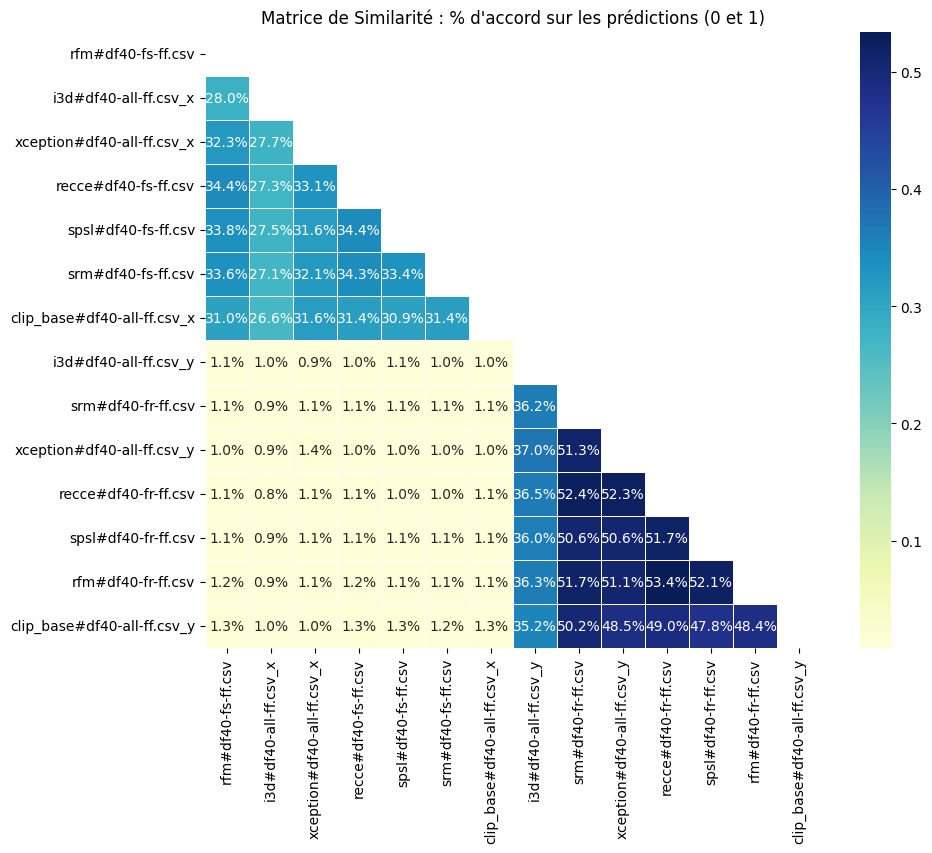

In [13]:
def calc_similarity_matrix(df):
    cols = df.columns
    n = len(cols)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            # % de fois où la prédiction est identique
            agreement = (df.iloc[:, i] == df.iloc[:, j]).mean()
            matrix[i, j] = agreement
            
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_sim = calc_similarity_matrix(df_finale.drop(["video_path", "label"], axis='columns'))

# 3. Affichage du Heatmap
mask = np.triu(np.ones_like(df_sim, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_sim, 
    mask=mask,         # <-- C'est ici que la magie opère !
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,         # Optionnel : force les cases à être carrées
    linewidths=0.5       # Optionnel : ajoute un petit espace entre les cases
)

plt.title("Matrice de Similarité : % d'accord sur les prédictions (0 et 1)")
plt.show()

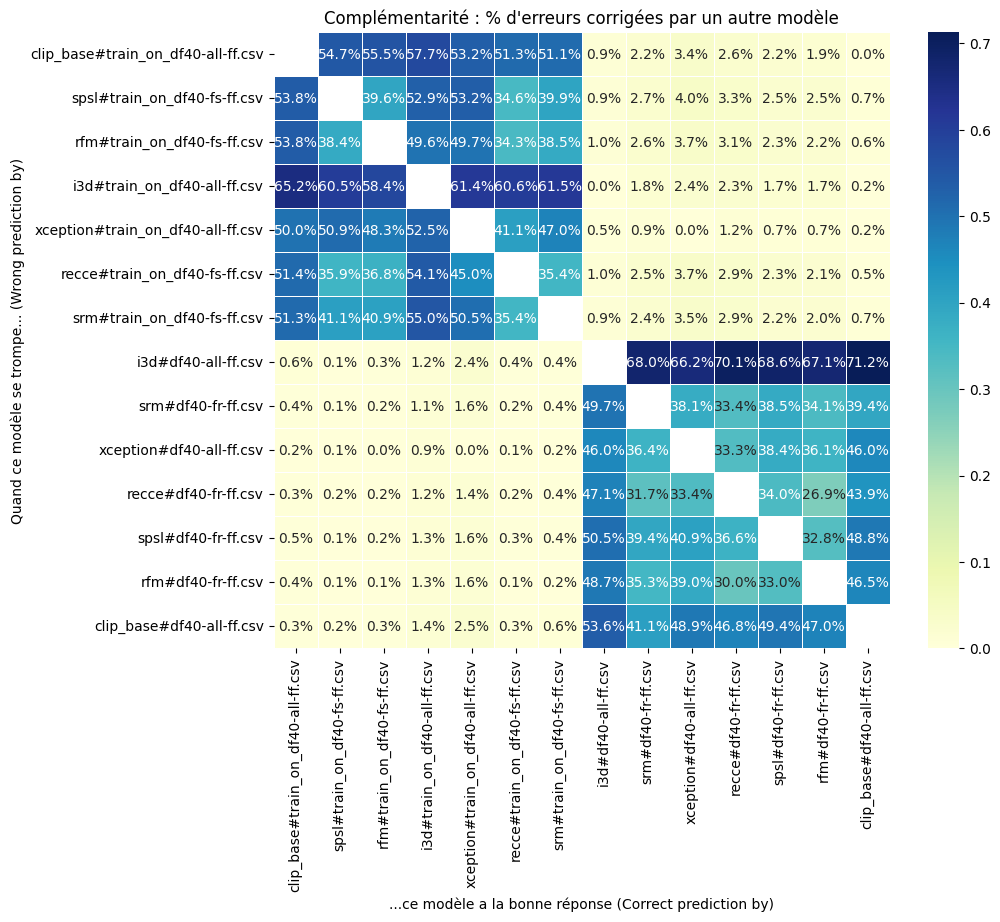

In [6]:
def calc_complementarity(df):
    cols = df.columns
    matrix = np.zeros((len(cols), len(cols)))
    
    for i, det_a in enumerate(cols):
        for j, det_b in enumerate(cols):
            if i == j:
                matrix[i, j] = 1.0 # Un détecteur ne s'aide pas lui-même
                continue
            
            # Masque : vidéos où A a FAUX (0)
            errors_a = df[det_a] == 0
            
            if errors_a.sum() == 0:
                matrix[i, j] = 0 # A n'a aucune erreur, B n'ajoute rien
            else:
                # % de fois où B a JUSTE (1) quand A a FAUX (0)
                savings = (df.loc[errors_a, det_b] == 1).mean()
                matrix[i, j] = savings
                
    return pd.DataFrame(matrix, index=cols, columns=cols)

df_comp = calc_complementarity(df_finale.drop(["video_path", "label"], axis='columns'))

# 1. Création d'un masque uniquement pour la diagonale
# np.eye crée une matrice avec des 1 sur la diagonale et des 0 ailleurs
masque_diagonale = np.eye(len(df_comp), dtype=bool)

# 2. Affichage du Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_comp, 
    mask=masque_diagonale, # On cache juste la diagonale
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1%",
    square=True,
    linewidths=0.5
)

plt.title("Complémentarité : % d'erreurs corrigées par un autre modèle")
plt.ylabel("Quand ce modèle se trompe... (Wrong prediction by)")
plt.xlabel("...ce modèle a la bonne réponse (Correct prediction by)")

plt.show()

In [8]:
df_comp

,clip_base#train_on_df40-all-ff.csv,spsl#train_on_df40-fs-ff.csv,rfm#train_on_df40-fs-ff.csv,i3d#train_on_df40-all-ff.csv,xception#train_on_df40-all-ff.csv,recce#train_on_df40-fs-ff.csv,srm#train_on_df40-fs-ff.csv,i3d#df40-all-ff.csv,srm#df40-fr-ff.csv,xception#df40-all-ff.csv,recce#df40-fr-ff.csv,spsl#df40-fr-ff.csv,rfm#df40-fr-ff.csv,clip_base#df40-all-ff.csv
clip_base#train_on_df40-all-ff.csv,1.000000,0.546521,0.554904,0.576697,0.532272,0.512992,0.511316,0.009220,0.021794,0.033529,0.025985,0.021794,0.019279,0.000000
spsl#train_on_df40-fs-ff.csv,0.538396,1.000000,0.395904,0.529010,0.532423,0.345563,0.399317,0.009386,0.027304,0.040102,0.033276,0.024744,0.024744,0.006826
rfm#train_on_df40-fs-ff.csv,0.538261,0.384348,1.000000,0.495652,0.497391,0.342609,0.385217,0.009565,0.026087,0.036522,0.031304,0.023478,0.021739,0.006087
i3d#train_on_df40-all-ff.csv,0.651643,0.604695,0.584038,1.000000,0.614085,0.605634,0.615023,0.000000,0.017840,0.024413,0.022535,0.016901,0.016901,0.001878
xception#train_on_df40-all-ff.csv,0.500448,0.509400,0.482543,0.524620,1.000000,0.410922,0.470009,0.005372,0.008953,0.000000,0.011638,0.007162,0.007162,0.001791
recce#train_on_df40-fs-ff.csv,0.514214,0.358696,0.367893,0.540970,0.449833,1.000000,0.353679,0.010033,0.025084,0.036789,0.029264,0.023411,0.020903,0.005017
srm#train_on_df40-fs-ff.csv,0.512542,0.411371,0.408863,0.550167,0.505017,0.353679,1.000000,0.009197,0.024247,0.035117,0.029264,0.021739,0.020067,0.006689
i3d#df40-all-ff.csv,0.006342,0.000705,0.002819,0.011980,0.023961,0.004228,0.004228,1.000000,0.680056,0.661734,0.701198,0.686399,0.670895,0.712474
srm#df40-fr-ff.csv,0.003591,0.001197,0.002394,0.011370,0.015560,0.002394,0.003591,0.497307,1.000000,0.380610,0.333932,0.384800,0.340515,0.394375
xception#df40-all-ff.csv,0.002459,0.000615,0.000000,0.009219,0.000000,0.001229,0.001844,0.460356,0.363860,1.000000,0.333128,0.383528,0.361401,0.459742


In [13]:
df_finale

,video_path,label,i3d#df40-all-ff.csv,srm#df40-fr-ff.csv,xception#df40-all-ff.csv,recce#df40-fr-ff.csv,spsl#df40-fr-ff.csv,rfm#df40-fr-ff.csv,clip_base#df40-all-ff.csv
0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,0,0,0,0,0
1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,1,0,1,1
2,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,0,0,0,0,0,0
3,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,1,1,1,1,0
4,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...
7943,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,1,1,1,0
7944,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,0,1,1,0
7945,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,0,0,0,0,0
7946,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1.0,1.0,0,1,0,0,0,0


In [80]:
def calc_common_errors(df):
    cols = df.columns
    matrix = np.zeros((len(cols), len(cols)))
    
    for i, det_a in enumerate(cols):
        for j, det_b in enumerate(cols):
            if i == j:
                matrix[i, j] = 1.0 # Un modèle partage 100% de ses erreurs avec lui-même
                continue
            
            # On isole les vidéos où le modèle A s'est trompé (valeur == 0)
            erreurs_a = (df[det_a] == 0)
            
            if erreurs_a.sum() == 0:
                matrix[i, j] = 0 # Si A ne fait aucune erreur
            else:
                # Parmi les erreurs de A, combien de fois B s'est-il AUSSI trompé (valeur == 0) ?
                # .mean() donne directement la proportion (le pourcentage)
                proportion_commune = (df.loc[erreurs_a, det_b] == 0).mean()
                matrix[i, j] = proportion_commune
                
    return pd.DataFrame(matrix, index=cols, columns=cols)

# On applique la fonction sur vos 7 colonnes de modèles
# (Assurez-vous de filtrer uniquement les colonnes du dataset df40_fs)
df_erreurs_communes = calc_common_errors(df_finale.drop(["video_path", "label"], axis="columns")) # Remplacez par vos 7 colonnes

In [65]:

df_finale

,video_path,label,i3d#df40-all-ff.csv,srm#df40-fr-ff.csv,xception#df40-all-ff.csv,recce#df40-fr-ff.csv,spsl#df40-fr-ff.csv,rfm#df40-fr-ff.csv,clip_base#df40-all-ff.csv
0,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,0,0,0,0,0
1,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,1,0,1,1
2,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,0,0,0,0,0,0
3,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,1,1,1,1,0
4,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,0.0,0.0,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...
7943,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,1,1,1,0
7944,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,1,0,1,1,0
7945,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,NaN,NaN,1,0,0,0,0,0
7946,/home/antoine/DF40/DeepfakeBench_DF40/deepfake...,1.0,1.0,0,1,0,0,0,0


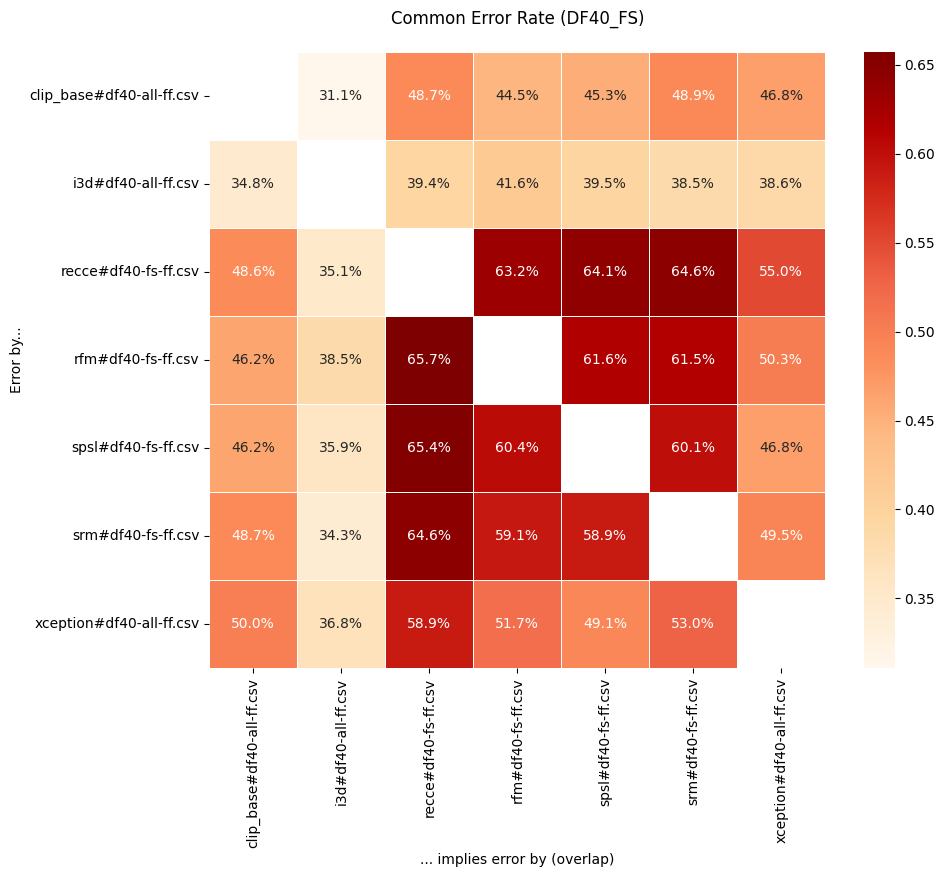

In [81]:
# Masque pour cacher la diagonale
masque_diagonale = np.eye(len(df_erreurs_communes), dtype=bool)

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_erreurs_communes, 
    mask=masque_diagonale,
    annot=True, 
    cmap="OrRd", # OrRd = Orange vers Rouge (parfait pour visualiser les faiblesses)
    fmt=".1%",
    square=True,
    linewidths=0.5,
)

plt.title("Common Error Rate (DF40_FS)", pad=20)
plt.ylabel("Error by...")
plt.xlabel("... implies error by (overlap)")

plt.show()

In [52]:
df_erreurs_communes

,rfm#df40-fs-ff.csv,i3d#df40-all-ff.csv,xception#df40-all-ff.csv,recce#df40-fs-ff.csv,spsl#df40-fs-ff.csv,srm#df40-fs-ff.csv,clip_base#df40-all-ff.csv
rfm#df40-fs-ff.csv,1.000000,0.385217,0.502609,0.657391,0.615652,0.614783,0.461739
i3d#df40-all-ff.csv,0.415962,1.000000,0.385915,0.394366,0.395305,0.384977,0.348357
xception#df40-all-ff.csv,0.517457,0.367950,1.000000,0.589078,0.490600,0.529991,0.499552
recce#df40-fs-ff.csv,0.632107,0.351171,0.550167,1.000000,0.641304,0.646321,0.485786
spsl#df40-fs-ff.csv,0.604096,0.359215,0.467577,0.654437,1.000000,0.600683,0.461604
srm#df40-fs-ff.csv,0.591137,0.342809,0.494983,0.646321,0.588629,1.000000,0.487458
clip_base#df40-all-ff.csv,0.445096,0.310981,0.467728,0.487008,0.453479,0.488684,1.000000


In [19]:
df_erreurs_communes

,i3d#df40-all-ff.csv,srm#df40-fr-ff.csv,xception#df40-all-ff.csv,recce#df40-fr-ff.csv,spsl#df40-fr-ff.csv,rfm#df40-fr-ff.csv,clip_base#df40-all-ff.csv
i3d#df40-all-ff.csv,1.000000,0.319944,0.338266,0.298802,0.313601,0.329105,0.287526
srm#df40-fr-ff.csv,0.271694,1.000000,0.619390,0.666068,0.615200,0.659485,0.605625
xception#df40-all-ff.csv,0.295022,0.636140,1.000000,0.666872,0.616472,0.638599,0.540258
recce#df40-fr-ff.csv,0.260123,0.682822,0.665644,1.000000,0.660123,0.731288,0.560736
spsl#df40-fr-ff.csv,0.262227,0.605775,0.591043,0.634060,1.000000,0.671774,0.512080
rfm#df40-fr-ff.csv,0.274383,0.647474,0.610458,0.700353,0.669800,1.000000,0.535253
clip_base#df40-all-ff.csv,0.237347,0.588714,0.511344,0.531704,0.505526,0.529959,1.000000


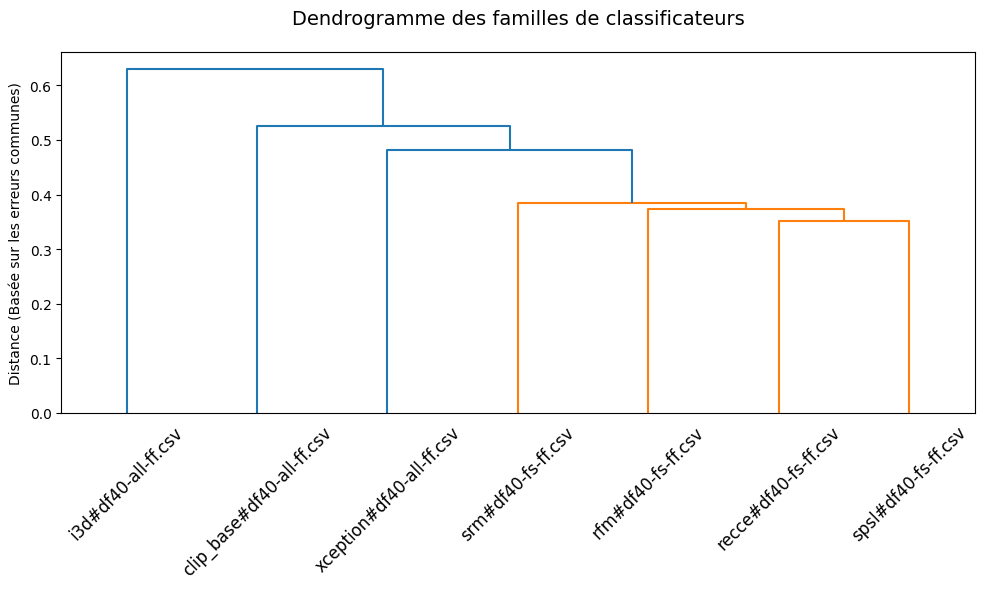

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# 1. On repart de votre matrice d'erreurs communes asymétrique
df_distance = 1.0 - df_erreurs_communes

# 2. LA CORRECTION EST ICI : On rend la matrice parfaitement symétrique
# On additionne la matrice avec sa transposée (.T) et on divise par 2 (la moyenne)
df_distance_symetrique = (df_distance + df_distance.T) / 2

# On s'assure que la diagonale est exactement à 0
np.fill_diagonal(df_distance_symetrique.values, 0)

# 3. Maintenant, squareform va accepter la matrice car elle est symétrique !
matrice_condensee = squareform(df_distance_symetrique)

# 4. Calcul du clustering et affichage
arbre_clustering = linkage(matrice_condensee, method='average')

plt.figure(figsize=(10, 6))

dendrogram(
    arbre_clustering, 
    labels=df_distance_symetrique.columns.tolist(), 
    leaf_rotation=45,                    
    leaf_font_size=12,
    color_threshold=0.4# Vous pourrez ajuster ce seuil pour changer les couleurs des familles
)

plt.title("Dendrogramme des familles de classificateurs", fontsize=14, pad=20)
plt.ylabel("Distance (Basée sur les erreurs communes)")

plt.tight_layout()
plt.show()

In [56]:
def calc_common_errors(df):
    cols = df.columns
    matrix = np.zeros((len(cols), len(cols)))
    
    for i, det_a in enumerate(cols):
        for j, det_b in enumerate(cols):
            if i == j:
                matrix[i, j] = 1.0 # Un modèle partage 100% de ses erreurs avec lui-même
                continue
            
            # On isole les vidéos où le modèle A s'est trompé (valeur == 0)
            erreurs_a = (df[det_a] == 0)
            
            if erreurs_a.sum() == 0:
                matrix[i, j] = 0 # Si A ne fait aucune erreur
            else:
                # Parmi les erreurs de A, combien de fois B s'est-il AUSSI trompé (valeur == 0) ?
                # .mean() donne directement la proportion (le pourcentage)
                proportion_commune = (df.loc[erreurs_a, det_b] == 0).mean()
                matrix[i, j] = proportion_commune
                
    return pd.DataFrame(matrix, index=cols, columns=cols)

# On applique la fonction sur vos 7 colonnes de modèles
# (Assurez-vous de filtrer uniquement les colonnes du dataset df40_fs)
df_erreurs_communes = calc_common_errors(df_finale.drop(["video_path", "label"], axis="columns")) # Remplacez par vos 7 colonnes

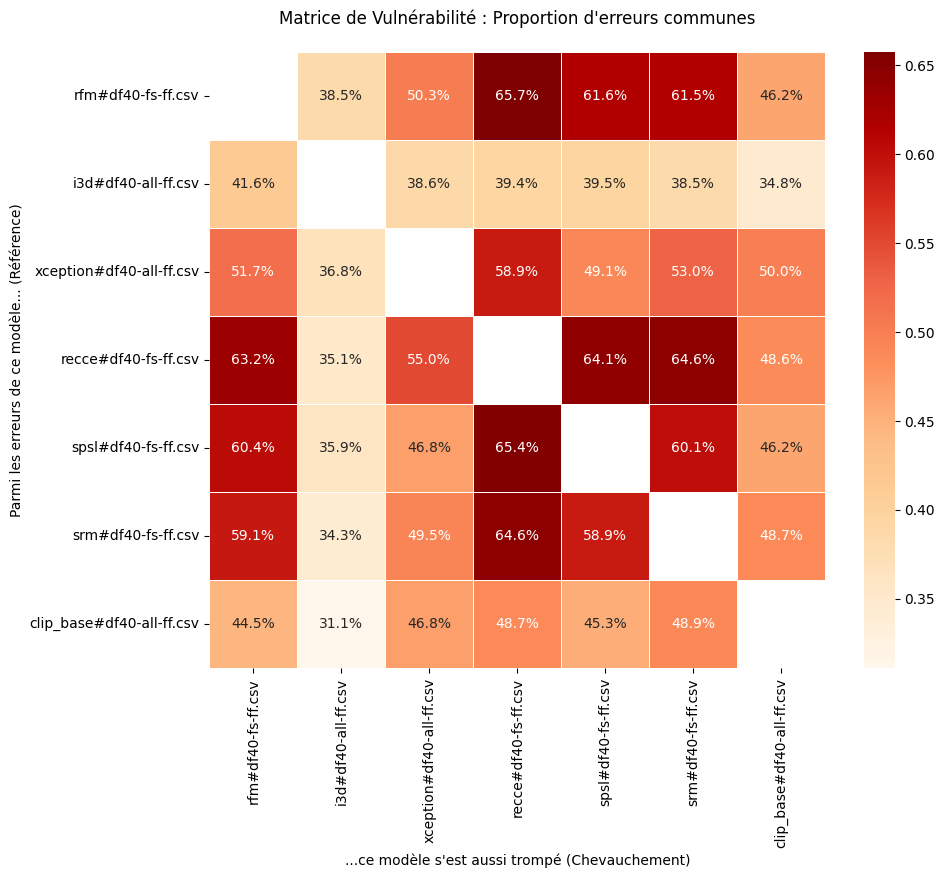

In [57]:
# Masque pour cacher la diagonale
masque_diagonale = np.eye(len(df_erreurs_communes), dtype=bool)

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_erreurs_communes, 
    mask=masque_diagonale,
    annot=True, 
    cmap="OrRd", # OrRd = Orange vers Rouge (parfait pour visualiser les faiblesses)
    fmt=".1%",
    square=True,
    linewidths=0.5
)

plt.title("Matrice de Vulnérabilité : Proportion d'erreurs communes", pad=20)
plt.ylabel("Parmi les erreurs de ce modèle... (Référence)")
plt.xlabel("...ce modèle s'est aussi trompé (Chevauchement)")

plt.show()

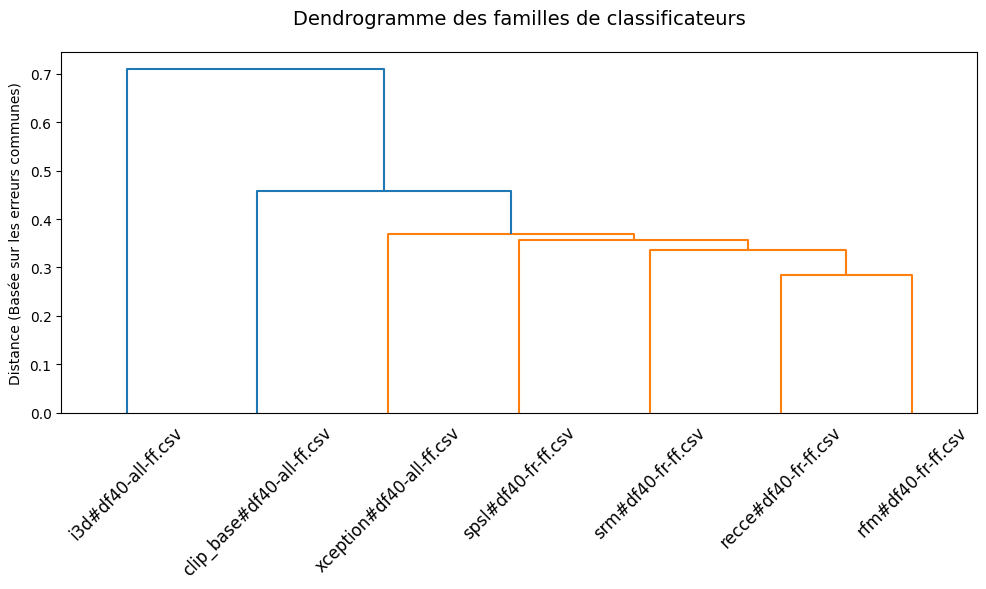

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# 1. On repart de votre matrice d'erreurs communes asymétrique
df_distance = 1.0 - df_erreurs_communes

# 2. LA CORRECTION EST ICI : On rend la matrice parfaitement symétrique
# On additionne la matrice avec sa transposée (.T) et on divise par 2 (la moyenne)
df_distance_symetrique = (df_distance + df_distance.T) / 2

# On s'assure que la diagonale est exactement à 0
np.fill_diagonal(df_distance_symetrique.values, 0)

# 3. Maintenant, squareform va accepter la matrice car elle est symétrique !
matrice_condensee = squareform(df_distance_symetrique)

# 4. Calcul du clustering et affichage
arbre_clustering = linkage(matrice_condensee, method='average')

plt.figure(figsize=(10, 6))

dendrogram(
    arbre_clustering, 
    labels=df_distance_symetrique.columns.tolist(), 
    leaf_rotation=45,                    
    leaf_font_size=12,
    color_threshold=0.4# Vous pourrez ajuster ce seuil pour changer les couleurs des familles
)

plt.title("Dendrogramme des familles de classificateurs", fontsize=14, pad=20)
plt.ylabel("Distance (Basée sur les erreurs communes)")

plt.tight_layout()
plt.show()